# fe02cr14 — Convergence Study & Magnetic Initialisation

Why fe02cr14 required AFM initialisation and what each computational decision did.  — they do not enter the ML training set.

`*Key finding*`
tot_mag=3.16 uB was pinned by QE two-Fermi-level scheme (nspin=2) — not a user constraint. Absolute magnetisation oscillated 5-8 uB for 300 iterations — spin structure never stabilised. Anti-ferromagnetic(AFM) sublattice initialisation (CrA/CrB parity) resolved this in ~50 iters.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DIAG = Path.home() / 'dft_projects' / 'fe-cr_cu-ni_DFT' / 'fe02cr14'
OUT  = Path.home() / 'dft_projects' / 'fe-cr_cu-ni_DFT' / 'analysis'
OUT.mkdir(exist_ok=True)

FILES = {
    'h+0.01 FM-plain'       : DIAG / 'fecr_fe02cr14_h0.01.out',
    'h-0.01 FM-plain'       : DIAG / 'fecr_fe02cr14_h-0.01.out',
    't+0.01 FM-plain'       : DIAG / 'fecr_fe02cr14_t0.01.out',
    'h0.00 pinned-localTF'  : DIAG / 'fecr_fe02cr14_h0.00.out',
    't0.00 pinned-localTF'  : DIAG / 'fecr_fe02cr14_t0.00.out',
    't-0.01 pinned-localTF' : DIAG / 'fecr_fe02cr14_t-0.01.out',
}

print('File status:')
for label, f in FILES.items():
    print(f'  {"OK" if f.exists() else "MISSING":<8} {label}')


/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


File status:
  OK       h+0.01 FM-plain
  OK       h-0.01 FM-plain
  OK       t+0.01 FM-plain
  OK       h0.00 pinned-localTF
  OK       t0.00 pinned-localTF
  OK       t-0.01 pinned-localTF


In [2]:
def parse_scf_accuracy(text):
    vals = re.findall(r'estimated scf accuracy\s*<\s*([\d\.E\+\-]+)', text)
    return np.array([float(v) for v in vals])

def parse_magnetization(text):
    tot = re.findall(r'^\s+total magnetization\s*=\s*([\-\d\.]+)\s+Bohr', text, re.M)
    ab  = re.findall(r'^\s+absolute magnetization\s*=\s*([\-\d\.]+)\s+Bohr', text, re.M)
    return np.array([float(x) for x in tot]), np.array([float(x) for x in ab])

def parse_meta(text):
    thr    = re.search(r'scf convergence threshold\s*=\s*([\d\.E\+\-]+)', text)
    conv   = re.search(r'convergence has been achieved in\s+(\d+)', text)
    mix    = re.search(r'number of iterations used =\s+\d+\s+(\S+)\s+mixing', text)
    beta   = re.search(r'mixing beta\s*=\s*([\d\.]+)', text)
    stress = re.findall(r'total   stress.*?P=\s*([\-\d\.]+)', text)
    return {
        'conv_thr' : thr.group(1) if thr else '?',
        'converged': int(conv.group(1)) if conv else None,
        'mixing'   : mix.group(1) if mix else '?',
        'beta'     : beta.group(1) if beta else '?',
        'P_kbar'   : float(stress[-1]) if stress else None,
    }

DATA = {}
for label, fpath in FILES.items():
    if not fpath.exists():
        print(f'SKIP: {fpath.name}')
        continue
    text = fpath.read_text()
    acc         = parse_scf_accuracy(text)
    tot_m, ab_m = parse_magnetization(text)
    meta        = parse_meta(text)
    DATA[label] = {'acc': acc, 'tot_mag': tot_m, 'abs_mag': ab_m, **meta}
    status = f'CONV {meta["converged"]}it' if meta['converged'] else f'FAILED {len(acc)}it best={min(acc):.1E}'
    print(f'{label:<28} mix={meta["mixing"]:<8} thr={meta["conv_thr"]}  -> {status}  P={meta["P_kbar"]} kbar')


h+0.01 FM-plain              mix=plain    thr=1.0E-07  -> CONV 51it  P=-85.32 kbar
h-0.01 FM-plain              mix=plain    thr=1.0E-07  -> CONV 56it  P=67.05 kbar
t+0.01 FM-plain              mix=plain    thr=1.0E-07  -> FAILED 161it best=1.5E-05  P=None kbar
h0.00 pinned-localTF         mix=local-TF thr=1.0E-07  -> FAILED 300it best=1.4E-06  P=None kbar
t0.00 pinned-localTF         mix=local-TF thr=1.0E-07  -> FAILED 300it best=1.9E-06  P=None kbar
t-0.01 pinned-localTF        mix=local-TF thr=1.0E-07  -> FAILED 300it best=2.1E-06  P=None kbar


`SCF Accuracy — All Runs`

Blue = converged FM plain. Red/orange = failed pinned local-TF.
All failed runs stall at ~1e-6 Ry — two orders above the 1e-7 target.
Crucially, **all three pinned runs stall at the same level regardless of strain mode** — this is a magnetic problem, not a numerical one.

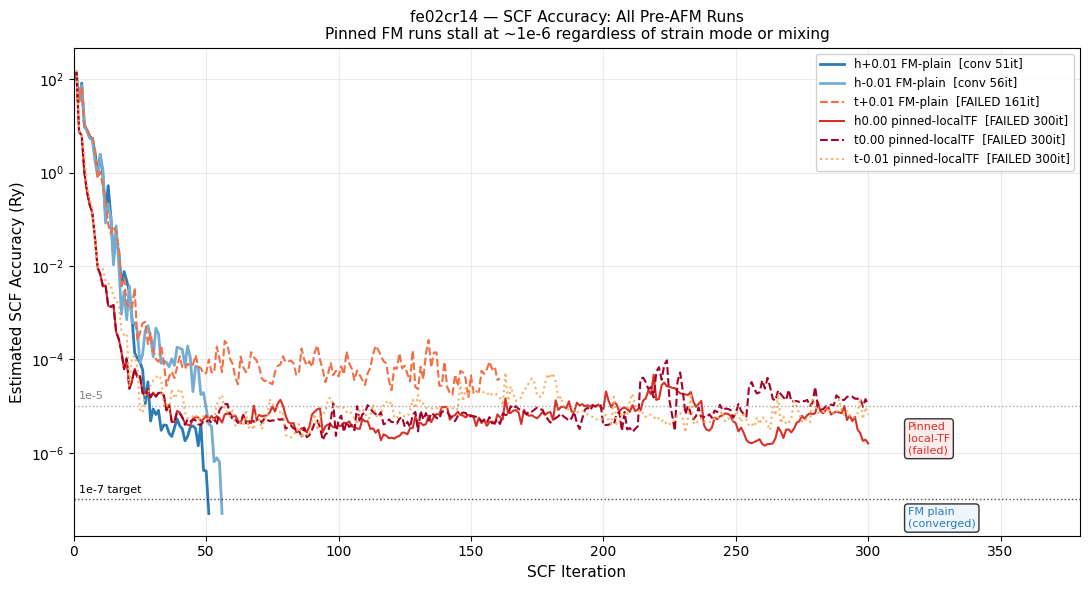

Saved -> /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/fe02cr14_scf_all_runs.png


In [7]:
STYLE = {
    'h+0.01 FM-plain'       : {'color': '#2c7bb6', 'ls': '-',  'lw': 2.0},
    'h-0.01 FM-plain'       : {'color': '#74add1', 'ls': '-',  'lw': 2.0},
    't+0.01 FM-plain'       : {'color': '#f46d43', 'ls': '--', 'lw': 1.5},
    'h0.00 pinned-localTF'  : {'color': '#d73027', 'ls': '-',  'lw': 1.5},
    't0.00 pinned-localTF'  : {'color': '#a50026', 'ls': '--', 'lw': 1.5},
    't-0.01 pinned-localTF' : {'color': '#fdae61', 'ls': ':',  'lw': 1.5},
}

fig, ax = plt.subplots(figsize=(11, 6))
for label, d in DATA.items():
    s = STYLE[label]
    status = f'conv {d["converged"]}it' if d['converged'] else f'FAILED {len(d["acc"])}it'
    ax.semilogy(range(1, len(d['acc'])+1), d['acc'],
                color=s['color'], ls=s['ls'], lw=s['lw'],
                label=f'{label}  [{status}]')

ax.axhline(1e-5, color='gray',  ls=':', lw=1, alpha=0.7)
ax.axhline(1e-7, color='black', ls=':', lw=1, alpha=0.7)
ax.text(2, 1.4e-5, '1e-5', fontsize=8, color='gray')
ax.text(2, 1.4e-7, '1e-7 target', fontsize=8, color='black')
ax.set_xlabel('SCF Iteration', fontsize=11)
ax.set_ylabel('Estimated SCF Accuracy (Ry)', fontsize=11)
ax.set_title('fe02cr14 — SCF Accuracy: All Pre-AFM Runs\n'
             'Pinned FM runs stall at ~1e-6 regardless of strain mode or mixing', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax.grid(True, which='both', alpha=0.25)
ax.set_xlim(0, 380)
ax.text(315, 4e-8, 'FM plain\n(converged)', fontsize=8, color='#2c7bb6',
        va='center', ha='left', bbox=dict(boxstyle='round,pad=0.3', fc='#eaf4fb', alpha=0.8))
ax.text(315, 2e-6, 'Pinned\nlocal-TF\n(failed)', fontsize=8, color='#d73027',
        va='center', ha='left', bbox=dict(boxstyle='round,pad=0.3', fc='#fde8e8', alpha=0.8))
plt.tight_layout()
fig.savefig(OUT / 'fe02cr14_scf_all_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUT}/fe02cr14_scf_all_runs.png')


## Figure 2: The Pinning Paradox — h0.00 Deep Dive

Three panels for the worst case (h0.00, 300 iters, no convergence):
- **Top:** SCF accuracy — stalls at ~1e-6, never crosses 1e-7
- **Middle:** tot_mag — frozen at 3.16 uB. This looks like convergence but is an artefact.
  QE nspin=2 fixes the electron count difference between spin channels, which pins tot_mag
  when starting from a FM guess. It does NOT mean the spin structure is physically converged.
- **Bottom:** abs_mag — oscillates 5-8 uB. This is the true indicator.
  Individual atomic moments are reorganising every iteration.

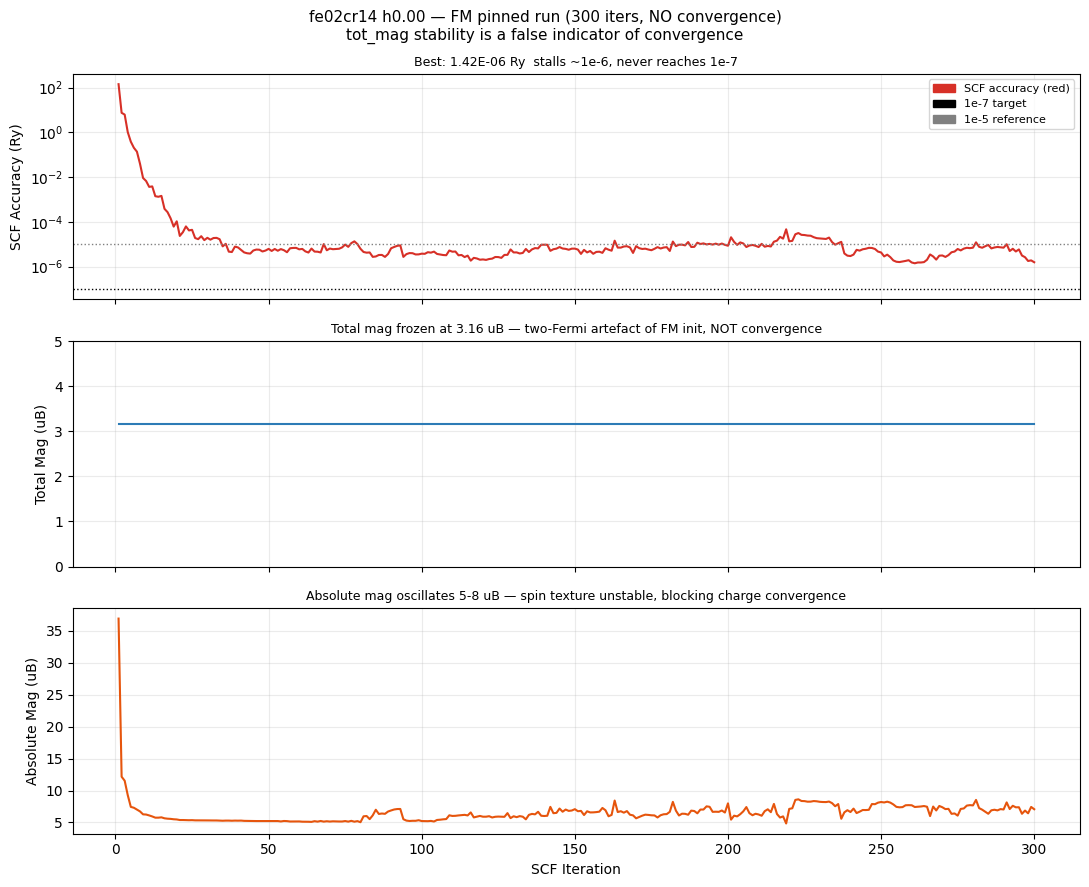

Saved -> /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/fe02cr14_pinning_paradox.png


In [8]:
from matplotlib.patches import Patch

key = 'h0.00 pinned-localTF'
d = DATA.get(key)
if d is None:
    print(f'{key} not loaded — check file path')
else:
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    fig.suptitle('fe02cr14 h0.00 — FM pinned run (300 iters, NO convergence)\n'
                 'tot_mag stability is a false indicator of convergence', fontsize=11)

    n = len(d['acc'])
    axes[0].semilogy(range(1, n+1), d['acc'], color='#d73027', lw=1.5)
    axes[0].axhline(1e-7, color='black', ls=':', lw=1, label='target 1e-7')
    axes[0].axhline(1e-5, color='gray',  ls=':', lw=1, label='1e-5 ref')
    axes[0].set_ylabel('SCF Accuracy (Ry)', fontsize=10)
    axes[0].set_title(f'Best: {min(d["acc"]):.2E} Ry  stalls ~1e-6, never reaches 1e-7', fontsize=9)
    axes[0].legend(handles=[
    Patch(color='#d73027', label='SCF accuracy (red)'),
    Patch(color='black',   label='1e-7 target'),
    Patch(color='gray',    label='1e-5 reference'),
], fontsize=8)
    axes[0].grid(True, which='both', alpha=0.25)

    nm = len(d['tot_mag'])
    axes[1].plot(range(1, nm+1), d['tot_mag'], color='#2c7bb6', lw=1.5)
    axes[1].set_ylabel('Total Mag (uB)', fontsize=10)
    axes[1].set_title('Total mag frozen at 3.16 uB — two-Fermi artefact of FM init, NOT convergence', fontsize=9)
    axes[1].set_ylim(0, 5)
    axes[1].grid(True, alpha=0.25)

    na = len(d['abs_mag'])
    axes[2].plot(range(1, na+1), d['abs_mag'], color='#e6550d', lw=1.5)
    axes[2].set_ylabel('Absolute Mag (uB)', fontsize=10)
    axes[2].set_xlabel('SCF Iteration', fontsize=10)
    axes[2].set_title('Absolute mag oscillates 5-8 uB — spin texture unstable, blocking charge convergence', fontsize=9)
    axes[2].grid(True, alpha=0.25)

    plt.tight_layout()
    fig.savefig(OUT / 'fe02cr14_pinning_paradox.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {OUT}/fe02cr14_pinning_paradox.png')


## Figure 3: Absolute Magnetisation — All 6 Runs

The two converged runs (h+0.01, h-0.01) show abs_mag settling cleanly. All four failed runs oscillate persistently. Note that t+0.01 (FM plain, no pinning) also failed — plain mixing alone was insufficient for tetragonal strain at this composition.

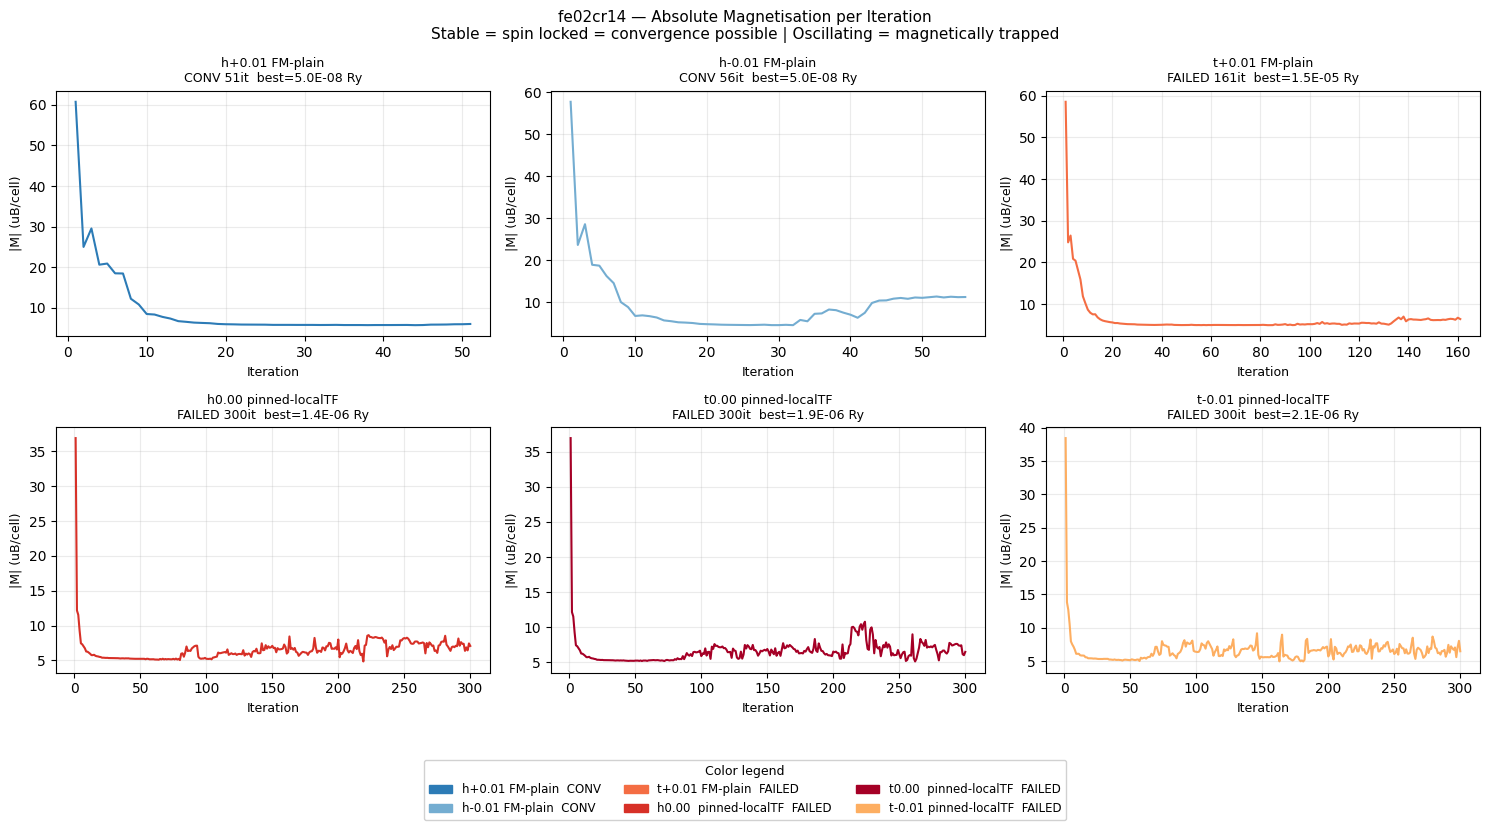

Saved -> /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/fe02cr14_abs_magnetization.png


In [11]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('fe02cr14 — Absolute Magnetisation per Iteration\n'
             'Stable = spin locked = convergence possible | Oscillating = magnetically trapped', fontsize=11)

colors = ['#2c7bb6', '#74add1', '#f46d43', '#d73027', '#a50026', '#fdae61']
for ax, (label, d), color in zip(axes.flat, DATA.items(), colors):
    ax.plot(range(1, len(d['abs_mag'])+1), d['abs_mag'], color=color, lw=1.5)
    status = f'CONV {d["converged"]}it' if d['converged'] else f'FAILED {len(d["acc"])}it'
    ax.set_title(f'{label}\n{status}  best={min(d["acc"]):.1E} Ry', fontsize=9)
    ax.set_xlabel('Iteration', fontsize=9)
    ax.set_ylabel('|M| (uB/cell)', fontsize=9)
    ax.grid(True, alpha=0.25)

legend_elements = [
    Patch(color='#2c7bb6', label='h+0.01 FM-plain  CONV'),
    Patch(color='#74add1', label='h-0.01 FM-plain  CONV'),
    Patch(color='#f46d43', label='t+0.01 FM-plain  FAILED'),
    Patch(color='#d73027', label='h0.00  pinned-localTF  FAILED'),
    Patch(color='#a50026', label='t0.00  pinned-localTF  FAILED'),
    Patch(color='#fdae61', label='t-0.01 pinned-localTF  FAILED'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.04),
           framealpha=0.9, title='Color legend', title_fontsize=9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(OUT / 'fe02cr14_abs_magnetization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUT}/fe02cr14_abs_magnetization.png')


## Summary Table & Text Report

In [10]:
rows = []
for label, d in DATA.items():
    rows.append({
        'file'         : label,
        'mixing'       : d['mixing'],
        'beta'         : d['beta'],
        'conv_thr'     : d['conv_thr'],
        'converged'    : d['converged'] if d['converged'] else 'NO',
        'iters'        : len(d['acc']),
        'best_acc'     : f"{min(d['acc']):.2E}",
        'abs_mag_range': f"{min(d['abs_mag']):.1f}-{max(d['abs_mag']):.1f} uB",
        'P_kbar'       : d['P_kbar'] if d['P_kbar'] is not None else 'none (no stress)',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

txt = OUT / 'fe02cr14_convergence_study.txt'
with open(txt, 'w') as f:
    f.write('fe02cr14 Convergence Study\n')
    f.write('=' * 60 + '\n\n')
    f.write('DIAGNOSTIC FILES ONLY. Not in ML training set.\n\n')
    f.write(df.to_string(index=False))
    f.write('\n\n--- Findings ---\n')
    f.write('1. tot_mag=3.16 uB pinned by QE two-Fermi-level (nspin=2) artefact.\n')
    f.write('   Appeared stable but masked underlying spin texture instability.\n\n')
    f.write('2. abs_mag oscillated 5-8 uB for 300 iters in all pinned runs.\n')
    f.write('   Spin texture reorganising every iter -> charge density cannot converge.\n\n')
    f.write('3. All pinned runs stall at ~1e-6 Ry regardless of strain mode or mixing.\n')
    f.write('   Root cause is magnetic, not numerical.\n\n')
    f.write('4. FM plain h+0.01 and h-0.01 converged cleanly in 51-56 iters.\n')
    f.write('   These feed C11+2C12 extraction. abs_mag stable.\n\n')
    f.write('5. t+0.01 FM plain failed (161 iters, best 1.49e-5).\n')
    f.write('   Tetragonal strain worsened magnetic frustration vs hydrostatic.\n\n')
    f.write('6. AFM sublattice init (CrA/CrB parity) resolved all three high-Cr tags\n')
    f.write('   in ~50 iters with conv_thr=1e-5. abs_mag locked immediately.\n\n')
    f.write('--- Dataset Flags for ML ---\n')
    f.write('C11+2C12 : FM h+/-0.01 (plain, 1e-7) -- internally consistent\n')
    f.write('C11-C12  : AFM tetra (local-TF, 1e-5) -- inconsistent with hydro setup\n')
    f.write('C44      : AFM shear (local-TF, 1e-5) -- inconsistent with hydro setup\n')
    f.write('ML flag  : afm_init=mixed, conv_thr=mixed, down-weight in training\n')

print(f'\nSaved -> {txt}')


                 file   mixing   beta conv_thr converged  iters best_acc abs_mag_range           P_kbar
      h+0.01 FM-plain    plain 0.3000  1.0E-07        51     51 5.00E-08   5.7-60.8 uB           -85.32
      h-0.01 FM-plain    plain 0.3000  1.0E-07        56     56 5.00E-08   4.6-57.7 uB            67.05
      t+0.01 FM-plain    plain 0.3000  1.0E-07        NO    161 1.49E-05   5.0-58.5 uB none (no stress)
 h0.00 pinned-localTF local-TF 0.1000  1.0E-07        NO    300 1.42E-06   4.8-36.9 uB none (no stress)
 t0.00 pinned-localTF local-TF 0.1000  1.0E-07        NO    300 1.87E-06   5.1-36.9 uB none (no stress)
t-0.01 pinned-localTF local-TF 0.1000  1.0E-07        NO    300 2.07E-06   4.9-38.5 uB none (no stress)

Saved -> /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/fe02cr14_convergence_study.txt
